# Support Vector Machine (SVM) for Drug Response Classification

## Assignment: Support Vector Machine

### Objective
The objective of this project is to build a Support Vector Machine (SVM) model to predict whether a patient will respond positively to a drug based on medical indicators.

### Dataset
Pharma_Industry.csv

### Target Variable
Drug Response
- 0 = No Response
- 1 = Positive Response

# Business Context

Pharmaceutical companies invest significant resources in testing drug effectiveness through clinical trials. However, not all patients respond similarly to a given drug due to biological and physiological differences.

Machine Learning can help predict drug response early, reducing costs and improving treatment outcomes. This project uses Support Vector Machine (SVM) to classify whether a patient will show a positive response to a drug.

# Import Required Libraries

In [1]:
# Data Handling
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# Evaluation Metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

# Ignore Warnings
import warnings
warnings.filterwarnings('ignore')

# Load Dataset

In [2]:
# Load Dataset

df = pd.read_csv("Pharma_Industry.csv")

# Display first 5 records
df.head()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
0,-0.128538,0.303280,-1.881849,0.258286,-0.792011,1
1,-1.846188,2.865142,-0.929511,2.866786,-0.719447,1
2,-1.252393,-1.541613,0.363632,-0.325370,0.191314,0
3,1.992515,-1.142779,-0.766657,0.975286,-0.823355,1
4,0.377100,0.538410,-0.029263,1.896015,-0.960130,1


# Basic Data Exploration


In [3]:
# Shape of Dataset

print("Rows and Columns :", df.shape)

Rows and Columns : (500, 6)


In [4]:
# Column Names

df.columns

Index(['Drug Dosage (mg)', 'Systolic Blood Pressure (mmHg)',
       'Heart Rate (BPM)', 'Liver Toxicity Index (U/L)',
       'Blood Glucose Level (mg/dL)', 'Drug Response'],
      dtype='object')

In [5]:
# Data Types

df.dtypes

Drug Dosage (mg)                  float64
Systolic Blood Pressure (mmHg)    float64
Heart Rate (BPM)                  float64
Liver Toxicity Index (U/L)        float64
Blood Glucose Level (mg/dL)       float64
Drug Response                       int64
dtype: object

In [6]:
# Dataset Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Drug Dosage (mg)                500 non-null    float64
 1   Systolic Blood Pressure (mmHg)  500 non-null    float64
 2   Heart Rate (BPM)                500 non-null    float64
 3   Liver Toxicity Index (U/L)      500 non-null    float64
 4   Blood Glucose Level (mg/dL)     500 non-null    float64
 5   Drug Response                   500 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 23.6 KB


In [7]:
# Statistical Summary

df.describe()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.0000
mean,-0.037761,0.214957,0.062871,0.054398,-0.171863,0.5200
std,0.979891,1.247567,0.971978,0.986001,0.983765,0.5001
min,-3.019512,-3.773897,-2.940389,-3.401277,-3.110431,0.0000
25%,-0.642003,-0.565168,-0.648157,-0.586085,-0.797715,0.0000
50%,-0.019340,0.201532,0.027732,-0.065661,-0.108106,1.0000
75%,0.641151,0.951375,0.710774,0.633914,0.513555,1.0000
max,2.949094,4.111751,3.193108,3.373269,2.518023,1.0000


# Missing Value Analysis

In [8]:
# Check Missing Values

df.isnull().sum()

Drug Dosage (mg)                  0
Systolic Blood Pressure (mmHg)    0
Heart Rate (BPM)                  0
Liver Toxicity Index (U/L)        0
Blood Glucose Level (mg/dL)       0
Drug Response                     0
dtype: int64

In [9]:
# Check Duplicate Records

df.duplicated().sum()

np.int64(0)

# Exploratory Data Analysis (EDA)

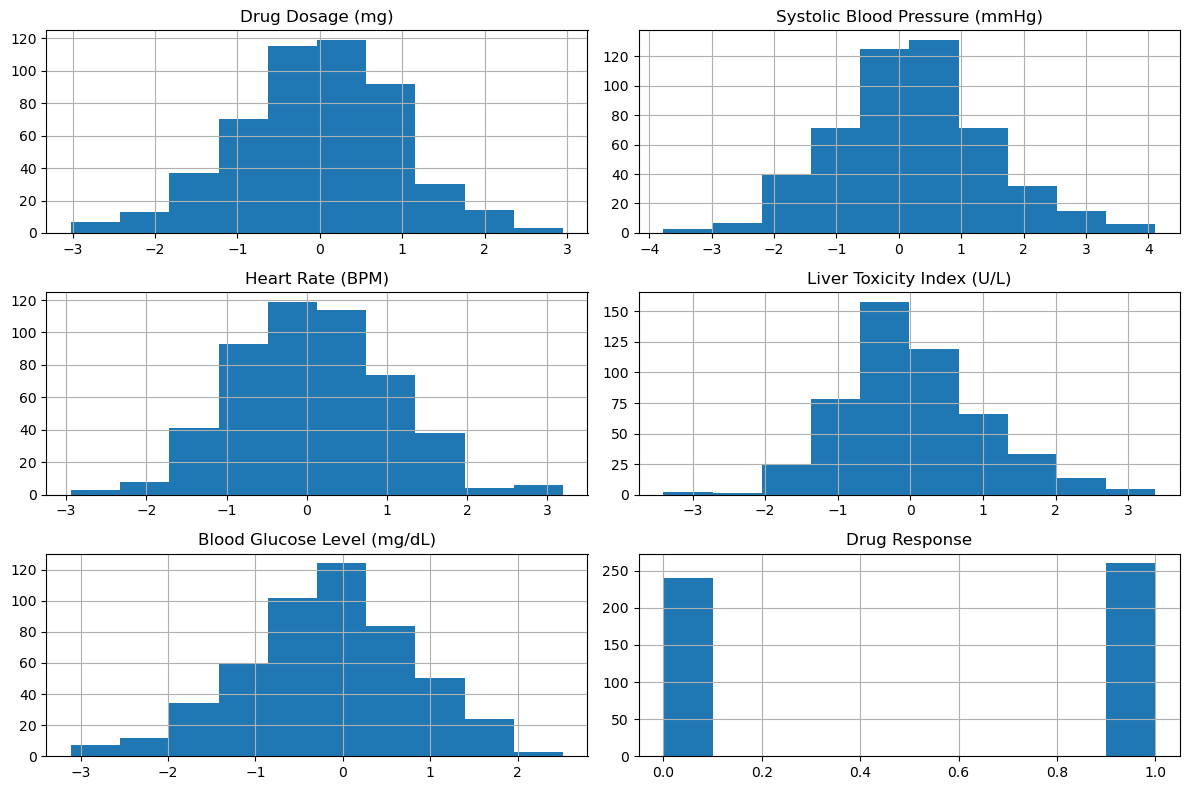

In [10]:
# Histograms for Numerical Features

df.hist(figsize=(12,8))
plt.tight_layout()
plt.show()

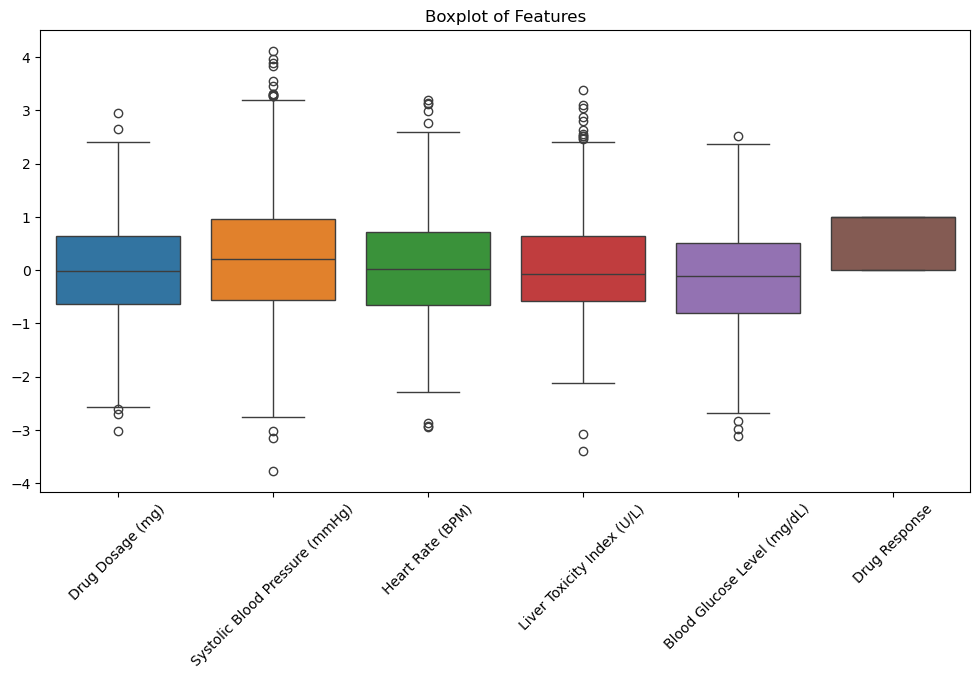

In [11]:
# Boxplots

plt.figure(figsize=(12,6))

sns.boxplot(data=df)

plt.xticks(rotation=45)
plt.title("Boxplot of Features")
plt.show()

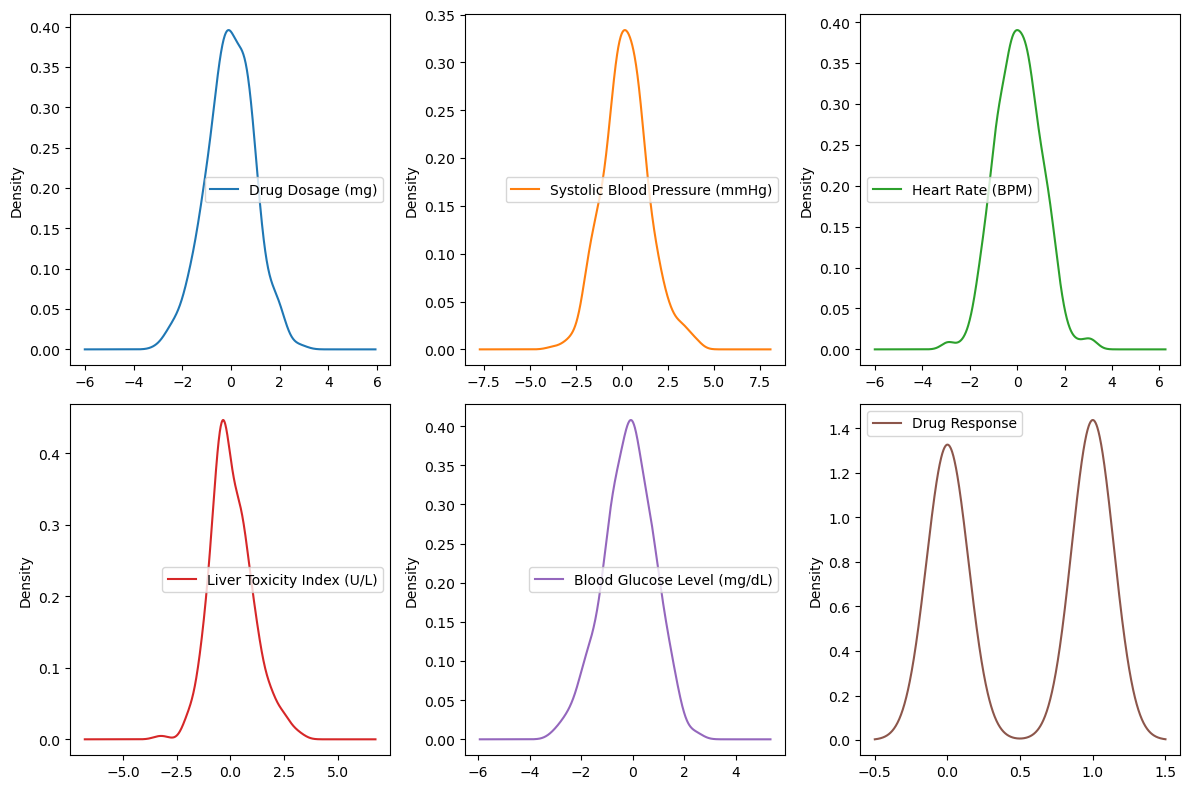

In [12]:
# Density Plots

df.plot(kind='density',
        subplots=True,
        layout=(2,3),
        figsize=(12,8),
        sharex=False)

plt.tight_layout()
plt.show()

# Correlation Analysis

In [13]:
# Correlation Matrix

corr = df.corr()

corr

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
Drug Dosage (mg),1.000000,0.090618,0.040571,0.128127,0.012434,0.043457
Systolic Blood Pressure (mmHg),0.090618,1.000000,-0.039195,0.283672,0.037228,0.305226
Heart Rate (BPM),0.040571,-0.039195,1.000000,0.005818,0.049897,-0.009715
Liver Toxicity Index (U/L),0.128127,0.283672,0.005818,1.000000,0.229474,0.434722
Blood Glucose Level (mg/dL),0.012434,0.037228,0.049897,0.229474,1.000000,0.169342
Drug Response,0.043457,0.305226,-0.009715,0.434722,0.169342,1.000000


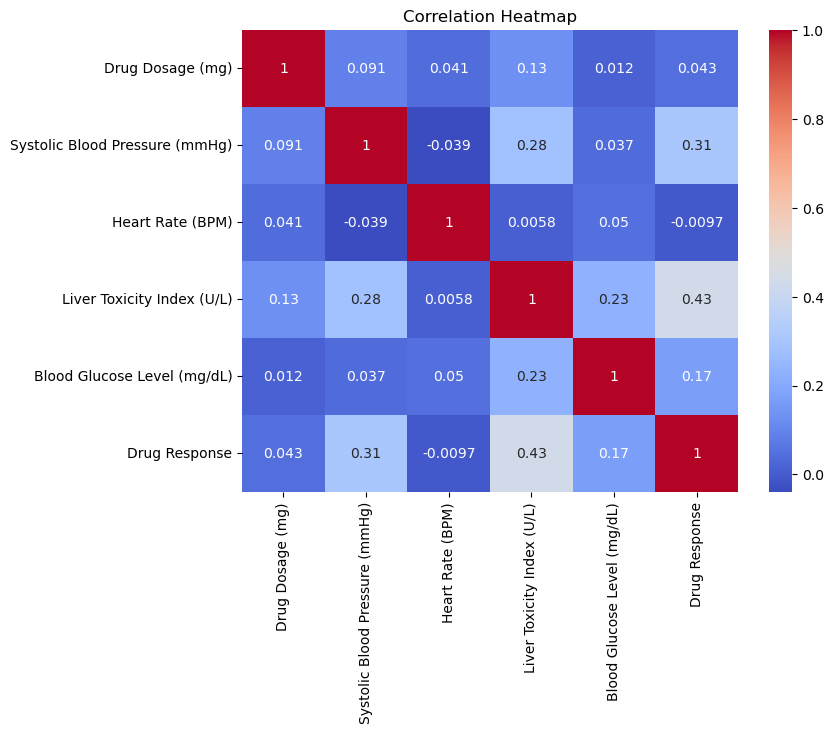

In [14]:
# Correlation Heatmap

plt.figure(figsize=(8,6))

sns.heatmap(corr,
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

# Class Distribution

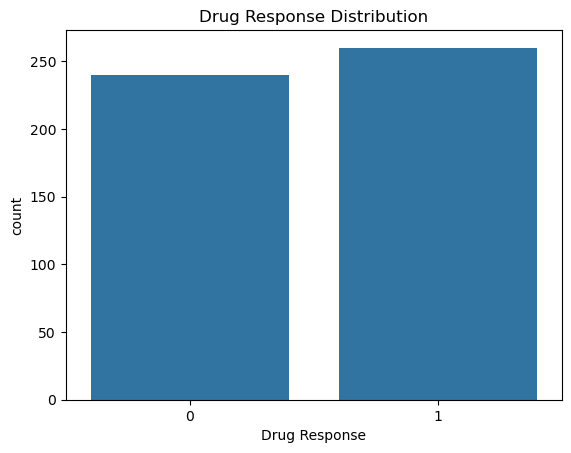

In [15]:
# Target Variable Distribution

sns.countplot(x='Drug Response', data=df)

plt.title("Drug Response Distribution")
plt.show()

# Pair Plot Visualization

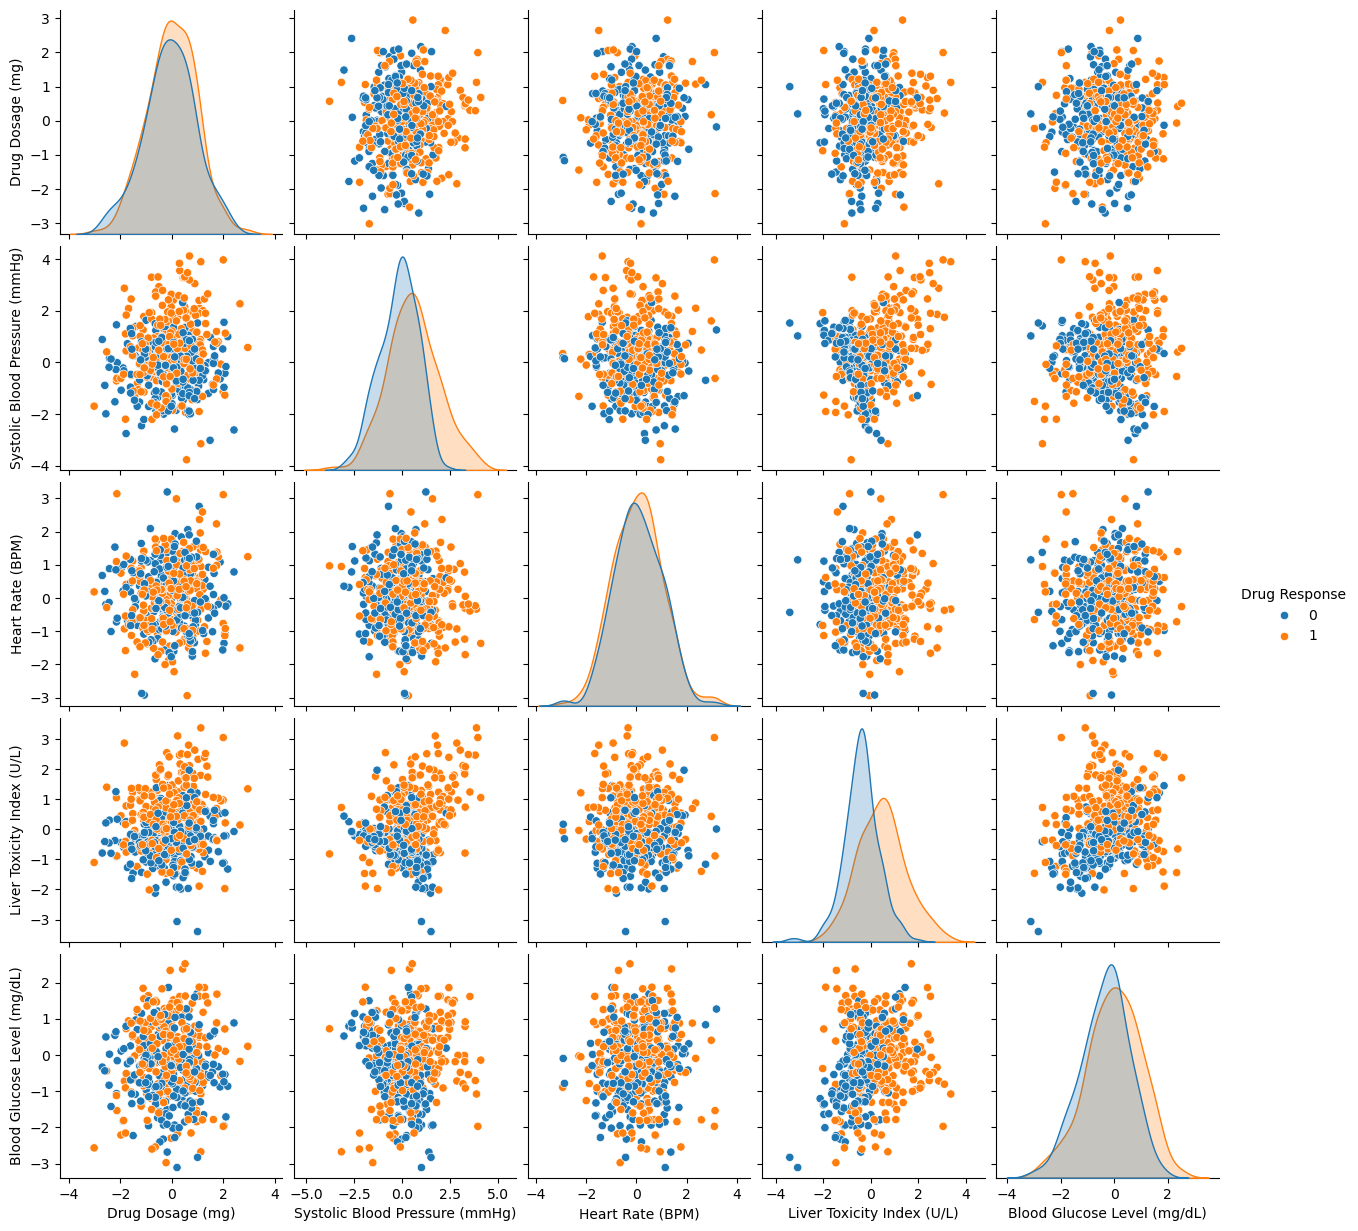

In [16]:
# Pair Plot

sns.pairplot(df,
             hue='Drug Response')

plt.show()

# Data Preprocessing

In this step, the dataset is divided into independent features (X) and target variable (y).

Features:
- Drug Dosage
- Systolic Blood Pressure
- Heart Rate
- Liver Toxicity Index
- Blood Glucose Level

Target:
- Drug Response

In [17]:
# Separate Features and Target Variable

X = df.drop('Drug Response', axis=1)

y = df['Drug Response']

print("Feature Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Shape : (500, 5)
Target Shape : (500,)


# Train-Test Split

The dataset is divided into training and testing sets.

- Training Data = 80%
- Testing Data = 20%

In [18]:
# Split Dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Data Shape :", X_train.shape)
print("Testing Data Shape :", X_test.shape)

Training Data Shape : (400, 5)
Testing Data Shape : (100, 5)


# Feature Scaling

Support Vector Machine is sensitive to feature scales.

StandardScaler is applied to standardize all features.

In [19]:
# Feature Scaling

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Scaling Completed Successfully")

Scaling Completed Successfully


# SVM Model Using Linear Kernel

A Support Vector Machine model is created using the Linear Kernel.

In [20]:
# Create Linear SVM Model

linear_svm = SVC(kernel='linear')

# Train Model

linear_svm.fit(X_train_scaled, y_train)

print("Linear SVM Model Trained Successfully")

Linear SVM Model Trained Successfully


# Prediction Using Linear SVM

In [21]:
# Predictions

y_pred_linear = linear_svm.predict(X_test_scaled)

y_pred_linear[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

# Model Evaluation - Linear Kernel

In [22]:
# Accuracy Score

linear_accuracy = accuracy_score(y_test, y_pred_linear)

print("Accuracy :", round(linear_accuracy,4))

Accuracy : 0.78


In [23]:
# Confusion Matrix

cm_linear = confusion_matrix(y_test, y_pred_linear)

print(cm_linear)

[[36  8]
 [14 42]]


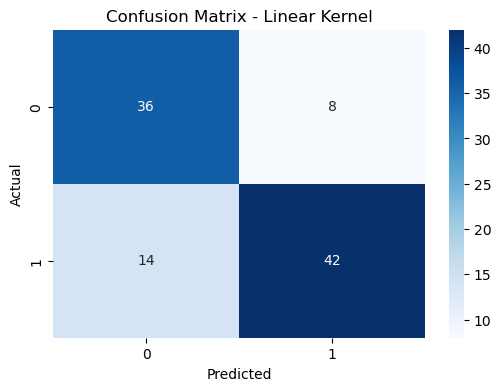

In [24]:
# Confusion Matrix Heatmap

plt.figure(figsize=(6,4))

sns.heatmap(cm_linear,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("Confusion Matrix - Linear Kernel")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [25]:
# Classification Report

print(classification_report(y_test, y_pred_linear))

              precision    recall  f1-score   support

           0       0.72      0.82      0.77        44
           1       0.84      0.75      0.79        56

    accuracy                           0.78       100
   macro avg       0.78      0.78      0.78       100
weighted avg       0.79      0.78      0.78       100



In [26]:
# Precision, Recall and F1 Score

precision = precision_score(y_test, y_pred_linear)

recall = recall_score(y_test, y_pred_linear)

f1 = f1_score(y_test, y_pred_linear)

print("Precision :", round(precision,4))
print("Recall :", round(recall,4))
print("F1 Score :", round(f1,4))

Precision : 0.84
Recall : 0.75
F1 Score : 0.7925


# SVM Model Using Polynomial Kernel

In this step, a Support Vector Machine model is trained using the Polynomial Kernel.

Polynomial kernels are useful when the relationship between features and target variable is non-linear.

In [27]:
# Create Polynomial Kernel SVM Model

poly_svm = SVC(kernel='poly')

# Train Model

poly_svm.fit(X_train_scaled, y_train)

print("Polynomial Kernel SVM Model Trained Successfully")

Polynomial Kernel SVM Model Trained Successfully


# Prediction Using Polynomial Kernel

In [28]:
# Predictions

y_pred_poly = poly_svm.predict(X_test_scaled)

y_pred_poly[:10]

array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0])

# Evaluation of Polynomial Kernel

In [29]:
# Accuracy Score

poly_accuracy = accuracy_score(y_test, y_pred_poly)

print("Polynomial Kernel Accuracy :", round(poly_accuracy,4))

Polynomial Kernel Accuracy : 0.71


In [30]:
# Confusion Matrix

cm_poly = confusion_matrix(y_test, y_pred_poly)

print(cm_poly)

[[40  4]
 [25 31]]


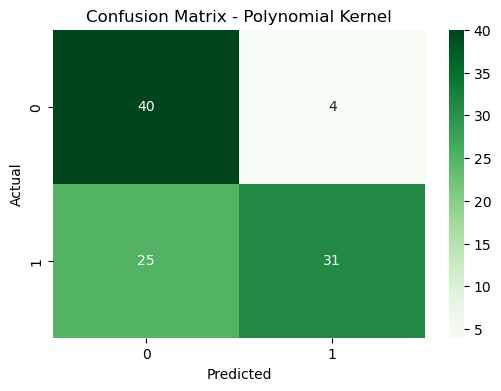

In [31]:
# Confusion Matrix Heatmap

plt.figure(figsize=(6,4))

sns.heatmap(cm_poly,
            annot=True,
            fmt='d',
            cmap='Greens')

plt.title("Confusion Matrix - Polynomial Kernel")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [32]:
# Classification Report

print(classification_report(y_test, y_pred_poly))

              precision    recall  f1-score   support

           0       0.62      0.91      0.73        44
           1       0.89      0.55      0.68        56

    accuracy                           0.71       100
   macro avg       0.75      0.73      0.71       100
weighted avg       0.77      0.71      0.70       100



# SVM Model Using RBF Kernel

Radial Basis Function (RBF) Kernel is one of the most commonly used kernels for classification problems.

It can handle complex and non-linear relationships effectively.

In [33]:
# Create RBF Kernel Model

rbf_svm = SVC(kernel='rbf')

# Train Model

rbf_svm.fit(X_train_scaled, y_train)

print("RBF Kernel SVM Model Trained Successfully")

RBF Kernel SVM Model Trained Successfully


In [34]:
# Predictions

y_pred_rbf = rbf_svm.predict(X_test_scaled)

y_pred_rbf[:10]

array([0, 0, 0, 0, 0, 0, 1, 0, 0, 0])

In [35]:
# Accuracy Score

rbf_accuracy = accuracy_score(y_test, y_pred_rbf)

print("RBF Kernel Accuracy :", round(rbf_accuracy,4))

RBF Kernel Accuracy : 0.84


In [36]:
# Confusion Matrix

cm_rbf = confusion_matrix(y_test, y_pred_rbf)

print(cm_rbf)

[[37  7]
 [ 9 47]]


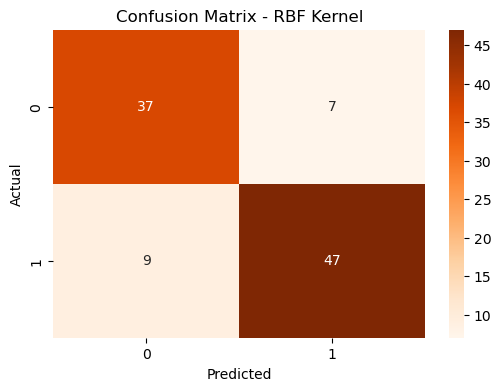

In [37]:
# Confusion Matrix Heatmap

plt.figure(figsize=(6,4))

sns.heatmap(cm_rbf,
            annot=True,
            fmt='d',
            cmap='Oranges')

plt.title("Confusion Matrix - RBF Kernel")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [38]:
# Classification Report

print(classification_report(y_test, y_pred_rbf))

              precision    recall  f1-score   support

           0       0.80      0.84      0.82        44
           1       0.87      0.84      0.85        56

    accuracy                           0.84       100
   macro avg       0.84      0.84      0.84       100
weighted avg       0.84      0.84      0.84       100



In [39]:
# Precision, Recall and F1 Score for RBF

precision_rbf = precision_score(y_test, y_pred_rbf)

recall_rbf = recall_score(y_test, y_pred_rbf)

f1_rbf = f1_score(y_test, y_pred_rbf)

print("Precision :", round(precision_rbf,4))
print("Recall :", round(recall_rbf,4))
print("F1 Score :", round(f1_rbf,4))

Precision : 0.8704
Recall : 0.8393
F1 Score : 0.8545


# Hyperparameter Tuning using GridSearchCV

Hyperparameter tuning helps identify the best combination of parameters for maximizing model performance.

In [40]:
# Import GridSearchCV

from sklearn.model_selection import GridSearchCV

In [41]:
# Define Parameter Grid

param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [1, 0.1, 0.01, 0.001],
    'kernel': ['rbf']
}

In [42]:
# Grid Search

grid = GridSearchCV(
    SVC(),
    param_grid,
    refit=True,
    verbose=1,
    cv=5
)

grid.fit(X_train_scaled, y_train)

Fitting 5 folds for each of 16 candidates, totalling 80 fits


,estimator,SVC()
,param_grid,"{'C': [0.1, 1, ...], 'gamma': [1, 0.1, ...], 'kernel': ['rbf']}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,100


In [43]:
# Best Parameters

print("Best Parameters:")
print(grid.best_params_)

Best Parameters:
{'C': 100, 'gamma': 0.01, 'kernel': 'rbf'}


In [44]:
# Best Score

print("Best Cross Validation Score:")
print(round(grid.best_score_,4))

Best Cross Validation Score:
0.7325


In [45]:
# Prediction Using Best Model

best_predictions = grid.predict(X_test_scaled)

In [46]:
# Accuracy of Tuned Model

best_accuracy = accuracy_score(y_test, best_predictions)

print("Tuned Model Accuracy :", round(best_accuracy,4))

Tuned Model Accuracy : 0.84


# Kernel Comparison

Comparing Linear, Polynomial, and RBF kernels based on Accuracy.

In [47]:
# Comparison Table

comparison = pd.DataFrame({
    'Kernel':['Linear','Polynomial','RBF'],
    'Accuracy':[linear_accuracy,
                poly_accuracy,
                rbf_accuracy]
})

comparison

,Kernel,Accuracy
0,Linear,0.78
1,Polynomial,0.71
2,RBF,0.84


In [48]:
# Sort Accuracy

comparison.sort_values(
    by='Accuracy',
    ascending=False
)

,Kernel,Accuracy
2,RBF,0.84
0,Linear,0.78
1,Polynomial,0.71


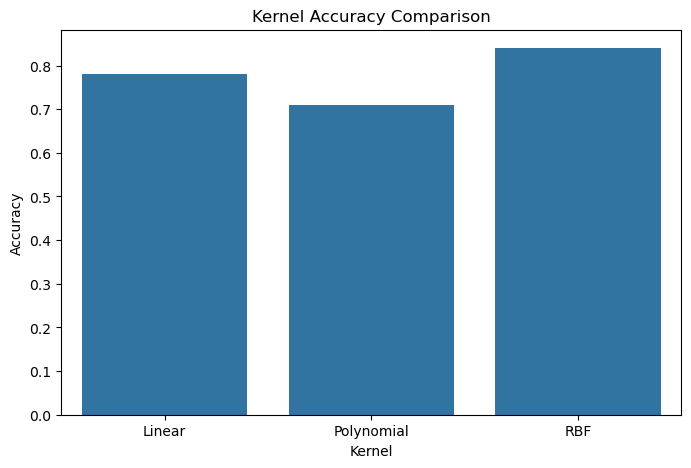

In [49]:
# Accuracy Comparison Chart

plt.figure(figsize=(8,5))

sns.barplot(
    x='Kernel',
    y='Accuracy',
    data=comparison
)

plt.title('Kernel Accuracy Comparison')
plt.show()

# Observations

1. Linear Kernel provides baseline classification performance.

2. Polynomial Kernel captures non-linear relationships but may increase computational complexity.

3. RBF Kernel generally performs better for complex classification tasks due to its flexibility.

4. Hyperparameter tuning further improves model performance by selecting optimal values of C and gamma.

# Strengths of Support Vector Machine (SVM)

- Effective in high-dimensional datasets.
- Works well for binary classification problems.
- Robust against overfitting when properly tuned.
- Can model both linear and non-linear relationships using kernels.
- Provides strong generalization performance.

# Limitations of Support Vector Machine (SVM)

- Computationally expensive for very large datasets.
- Sensitive to parameter selection.
- Training time increases with dataset size.
- Less interpretable compared to simple models like Logistic Regression.

# Real-World Applications

In the pharmaceutical industry, SVM can be used to:

- Predict patient drug response.
- Support personalized medicine.
- Reduce clinical trial costs.
- Improve treatment effectiveness.
- Assist healthcare professionals in decision making.

# Conclusion

A Support Vector Machine (SVM) model was successfully developed to classify drug responses using patient medical data.

Exploratory Data Analysis, preprocessing, feature scaling, and model training were performed successfully. Multiple kernels including Linear, Polynomial, and RBF were evaluated and compared.

Hyperparameter tuning was conducted using GridSearchCV to optimize model performance. The results demonstrate that SVM is a powerful classification algorithm capable of supporting drug response prediction and personalized healthcare solutions.